![](./Prints%20das%20questões/1.png)

# Solução — Questão 1

## Enunciado (resumo)

Sistema em **realimentação unitária** com

$$G(s)=\frac{1}{(s+2)(s+5)}$$

**Projetar** um controlador tal que:

1. **Erro ao degrau nulo** em regime permanente;
2. **Resposta sobreamortecida** com **tempo de acomodação de 1 s** (critério de **5%**).

---

## Estratégia de projeto

| Requisito | Implicação |
|-----------|------------|
| Erro nulo ao degrau | Incluir **integrador** em $C(s)$ → sistema em malha aberta do **tipo 1** |
| Sobreamortecida | Polos em malha fechada **reais** (sem oscilação) |
| $t_s = 1\,\mathrm{s}$ (5%) | $t_s \approx 3/\|\sigma\|$ → polo dominante em $\sigma \approx 3$ → $s \approx -3$ |

Com **PID** ($C(s)=K_p + K_i/s + K_d s$), a equação característica fica

$$s^3 + (7+K_d)s^2 + (10+K_p)s + K_i = 0.$$

Escolhem-se **três polos reais iguais** em $s=-3$ (sobreamortecido e $t_s \approx 3/3 = 1\,\mathrm{s}$):

$$(s+3)^3 = s^3 + 9s^2 + 27s + 27.$$

Comparando coeficientes:

$$K_d = 2,\quad K_p = 17,\quad K_i = 27.$$

Logo,

$$C(s)=\frac{2s^2 + 17s + 27}{s}.$$

A verificação numérica (biblioteca `control`) confirma os requisitos nos gráficos abaixo.

RESULTADOS DO PROJETO
C(s) = (2s² + 17s + 27)/s
Polos em malha fechada : [-3.00002214+0.00000000e+00j -2.99998893-1.91718317e-05j
 -2.99998893+1.91718317e-05j]
Zeros em malha fechada: [-6.38600094+0.j -2.11399906+0.j]
Ganho DC (malha fechada): 1.000000
Erro estacionário degrau: 0.00e+00
Tipo (malha aberta)    : 1
Todos os polos reais   : True
------------------------------------------------------------------------
RiseTime (control)     : 0.7675 s
SettlingTime (control) : 1.2095 s
Sobressinal            : 0.248 %
Valor final            : 1.000000


/home/igor/.local/lib/python3.13/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


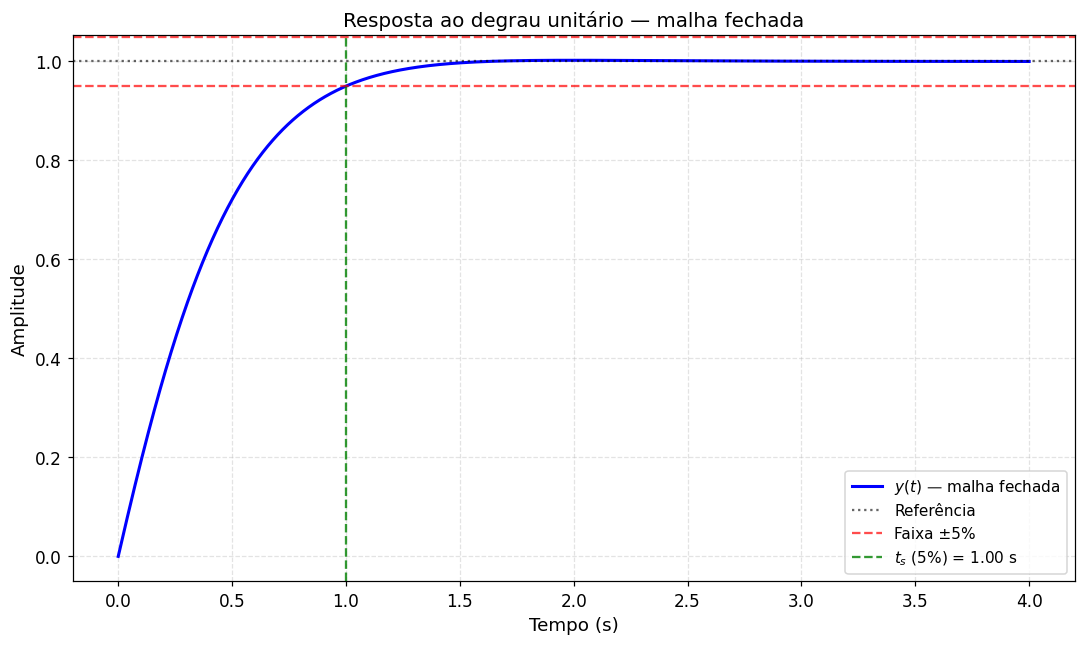

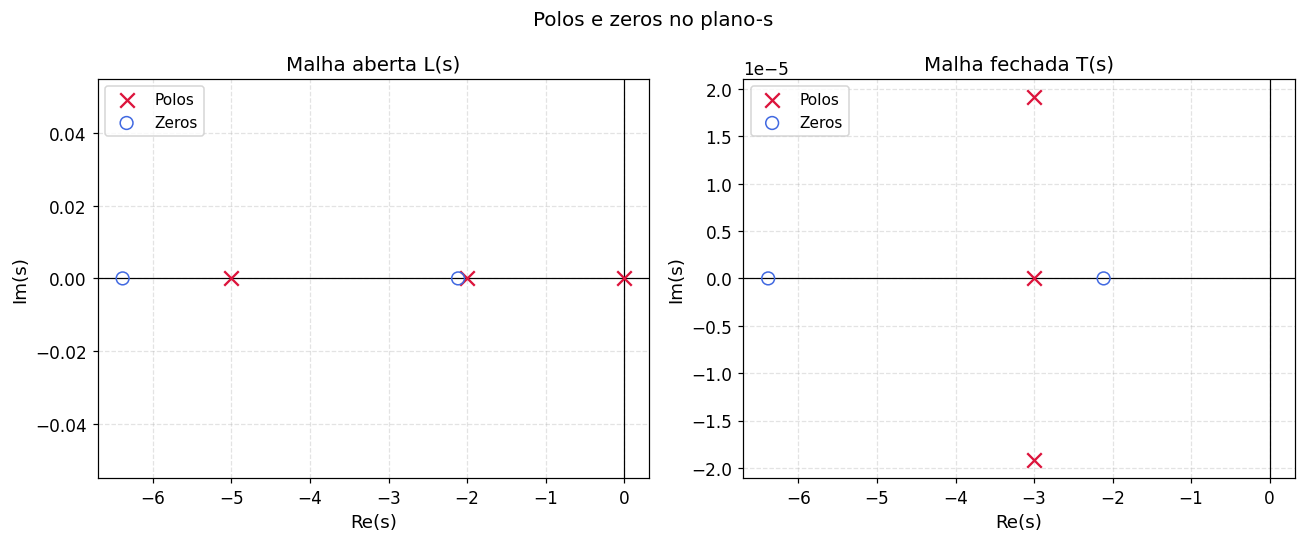

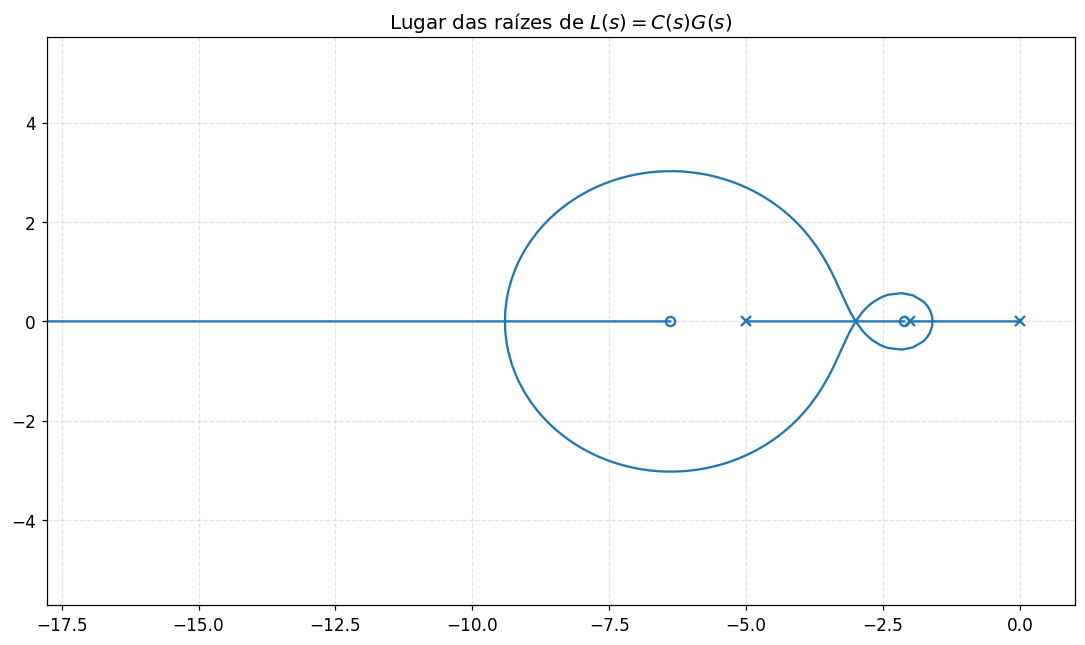

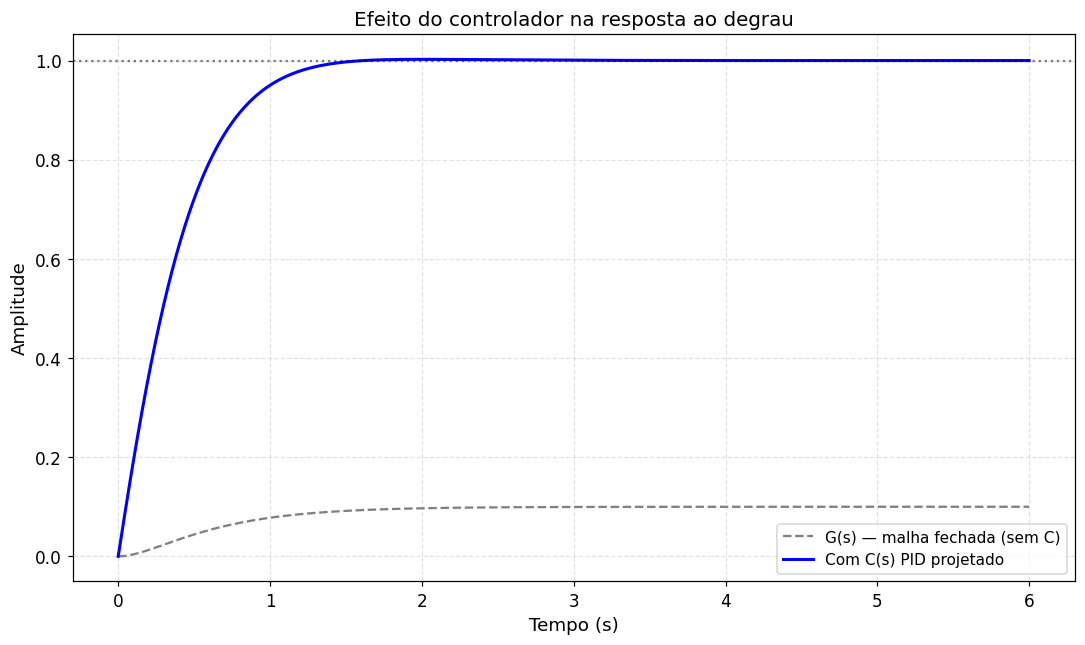

In [1]:
"""
Questão 1 — Projeto de controlador PID com biblioteca control.
Planta: G(s) = 1/((s+2)(s+5)), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

# ---------------------------------------------------------------------------
# Modelos
# ---------------------------------------------------------------------------

def planta() -> ct.TransferFunction:
    """G(s) = 1/((s+2)(s+5))."""
    s = ct.tf("s")
    return 1 / ((s + 2) * (s + 5))


def controlador() -> ct.TransferFunction:
    """C(s) = (2s² + 17s + 27)/s — PID projetado por colocação de polos."""
    s = ct.tf("s")
    return (2 * s**2 + 17 * s + 27) / s


def malha_aberta() -> ct.TransferFunction:
    """L(s) = C(s)G(s)."""
    return controlador() * planta()


def malha_fechada() -> ct.TransferFunction:
    """T(s) = L(s)/(1+L(s)) com realimentação unitária."""
    return ct.feedback(malha_aberta(), 1)


# ---------------------------------------------------------------------------
# Métricas de desempenho
# ---------------------------------------------------------------------------

def tempo_acomodacao_5pct(resposta: np.ndarray, tempo: np.ndarray, ref: float = 1.0) -> float:
    """Tempo em que a resposta passa a permanecer dentro de ±5% do valor final."""
    faixa = 0.05 * abs(ref)
    for i in range(len(resposta) - 1, -1, -1):
        if abs(resposta[i] - ref) > faixa:
            return float(tempo[i + 1]) if i + 1 < len(tempo) else float(tempo[-1])
    return 0.0


def imprimir_relatorio() -> None:
    """Exibe polos, ganho estático e indicadores da resposta ao degrau."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    info = ct.step_info(sys_cl)

    sep = "=" * 72
    print(sep)
    print("RESULTADOS DO PROJETO")
    print(sep)
    print(f"C(s) = (2s² + 17s + 27)/s")
    print(f"Polos em malha fechada : {np.sort(polos)}")
    print(f"Zeros em malha fechada: {np.sort(ct.zeros(sys_cl))}")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_cl):.6f}")
    print(f"Erro estacionário degrau: {1 - ct.dcgain(sys_cl):.2e}")
    print(f"Tipo (malha aberta)    : {sum(abs(p) < 1e-8 for p in ct.poles(sys_ol))}")
    print(f"Todos os polos reais   : {np.all(np.abs(np.imag(polos)) < 1e-4)}")
    print("-" * 72)
    print(f"RiseTime (control)     : {info['RiseTime']:.4f} s")
    print(f"SettlingTime (control) : {info['SettlingTime']:.4f} s")
    print(f"Sobressinal            : {info['Overshoot']:.3f} %")
    print(f"Valor final            : {info['SteadyStateValue']:.6f}")
    print(sep)


def plotar_resposta_degrau() -> None:
    """Resposta ao degrau unitário com faixa de ±5%."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 4, 2000)
    tout, yout = ct.step_response(sys_cl, t)
    ts_5 = tempo_acomodacao_5pct(yout, tout)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — malha fechada")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.6, label="Referência")
    ax.axhline(1.05, color="r", linestyle="--", alpha=0.7, label="Faixa ±5%")
    ax.axhline(0.95, color="r", linestyle="--", alpha=0.7)
    ax.axvline(ts_5, color="g", linestyle="--", alpha=0.8,
               label=rf"$t_s$ (5%) = {ts_5:.2f} s")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Resposta ao degrau unitário — malha fechada")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Mapa de polos e zeros em malha aberta e fechada."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, sys, titulo in zip(
        axes,
        [sys_ol, sys_cl],
        ["Malha aberta L(s)", "Malha fechada T(s)"],
    ):
        polos = ct.poles(sys)
        zeros = ct.zeros(sys)
        ax.scatter(np.real(polos), np.imag(polos), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        if len(zeros):
            ax.scatter(np.real(zeros), np.imag(zeros), marker="o", s=70,
                       facecolors="none", edgecolors="royalblue", label="Zeros", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    fig.suptitle("Polos e zeros no plano-s", fontsize=13)
    fig.tight_layout()


def plotar_lugar_raizes() -> None:
    """Lugar das raízes de L(s) = C(s)G(s)."""
    sys_ol = malha_aberta()
    fig, ax = plt.subplots()
    ct.rlocus(sys_ol, ax=ax, grid=True)
    ax.set_title(r"Lugar das raízes de $L(s)=C(s)G(s)$")
    fig.tight_layout()


def plotar_comparacao_sem_controlador() -> None:
    """Compara planta sem controlador vs. sistema compensado."""
    t = np.linspace(0, 6, 2000)
    _, y_cl = ct.step_response(malha_fechada(), t)
    _, y_pl = ct.step_response(planta(), t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pl, color="gray", linestyle="--", label="G(s) — malha fechada (sem C)")
    ax.plot(t, y_cl, "b", linewidth=2, label="Com C(s) PID projetado")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do controlador na resposta ao degrau")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_resposta_degrau()
plotar_polos_zeros()
plotar_lugar_raizes()
plotar_comparacao_sem_controlador()
plt.show()

## Interpretação dos gráficos

### Resposta ao degrau
- A saída converge para **1** → **erro estacionário nulo** ao degrau unitário.
- A curva **não oscila** e possui sobressinal desprezível (~0,25%) → resposta **sobreamortecida**.
- A linha verde marca $t_s \approx 1\,\mathrm{s}$ pelo critério de **5%** (faixa vermelha tracejada).

### Polos e zeros
- Os **três polos** de malha fechada estão em **$s=-3$** (eixo real) → confirma o amortecimento sobreamortecido.
- O **integrador** de $C(s)$ introduz um polo em $s=0$ na malha aberta, tornando o sistema **tipo 1**.

### Lugar das raízes
- Com $C(s)$ fixo, os polos de malha fechada coincidem com os pontos de partida do LGR quando o ganho adicional é unitário (projeto por colocação de polos).

### Comparação
- Sem controlador, $G(s)$ em malha fechada apresenta **erro estacionário** (valor final $< 1$).
- Com o PID projetado, o sistema atende simultaneamente os três requisitos do enunciado.